# Machine Learning — Homework 5: Clustering and PCA

**Course:** Machine Learning · **National University of Kyiv-Mohyla Academy (NaUKMA)**  
**Module 7:** Finding Structure Without Labels (Week 7) · **Instructor:** Dmytro Kuzmenko

**Meta**

| Field | Value |
|---|---|
| Points | 5 (1.25 per task) |
| Estimated time | 2.5–3.5 hours |
| Prerequisites | Modules 1–6; sklearn `KMeans`, `PCA`, `DBSCAN`, `silhouette_score` |
| Deadline | (placeholder — set on DistEdu) |

---

## AI Use Disclosure

Fill this in before submitting. Being honest here cannot lower your grade; hiding AI use and being caught can.

- **AI tools used:**
- **Nature of assistance:**
- **Representative prompts or relevant interaction:**
- **What I independently verified or changed:**

---

## Learning Objectives

- Choose the number of clusters with inertia and silhouette, and read the evidence honestly (elbow ambiguity).
- Explain why feature scaling changes k-means assignments and control it.
- Use PCA for visualization and compression, and interpret component plots.
- Identify the failure modes of distance-based clustering and decide when PCA is a preprocessing step versus a compression/visualization tool.

---

## Warm-up

Run the setup cell. All random processes are seeded.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs, load_digits
from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, adjusted_rand_score

np.random.seed(42)
%matplotlib inline
plt.rcParams["figure.dpi"] = 110
print("Setup complete.")

Setup complete.


## Guided Exercise

### Task 1: k-Means and Choosing k

**Experiment (A).** Generate 600 points from 4 well-separated Gaussian blobs (we know the ground truth — but a clustering algorithm must not). Run k-means for k in 2..10 and record inertia and silhouette score for each k.

In [2]:
Xb, yb = make_blobs(n_samples=600, centers=4, cluster_std=1.5, random_state=42)
print("Shape:", Xb.shape, "| true number of blobs: 4")

ks = np.arange(2, 11)
inertias, sils = [], []
for k in ks:
    km = KMeans(n_clusters=k, n_init=10, random_state=42).fit(Xb)
    inertias.append(km.inertia_)
    sils.append(silhouette_score(Xb, km.labels_))
results_k = pd.DataFrame({"k": ks, "inertia": np.round(inertias, 1), "silhouette": np.round(sils, 3)})
display(results_k)

Shape: (600, 2) | true number of blobs: 4


,k,inertia,silhouette
0,2,19984.7,0.557
1,3,5507.7,0.700
2,4,2587.8,0.682
3,5,2325.4,0.613
4,6,2085.4,0.505
5,7,1867.6,0.439
6,8,1659.0,0.332
7,9,1512.0,0.337
8,10,1359.9,0.345


**Evidence (C).** Plot inertia vs k (elbow) and silhouette vs k side by side, and visualize the assignments for your chosen k.

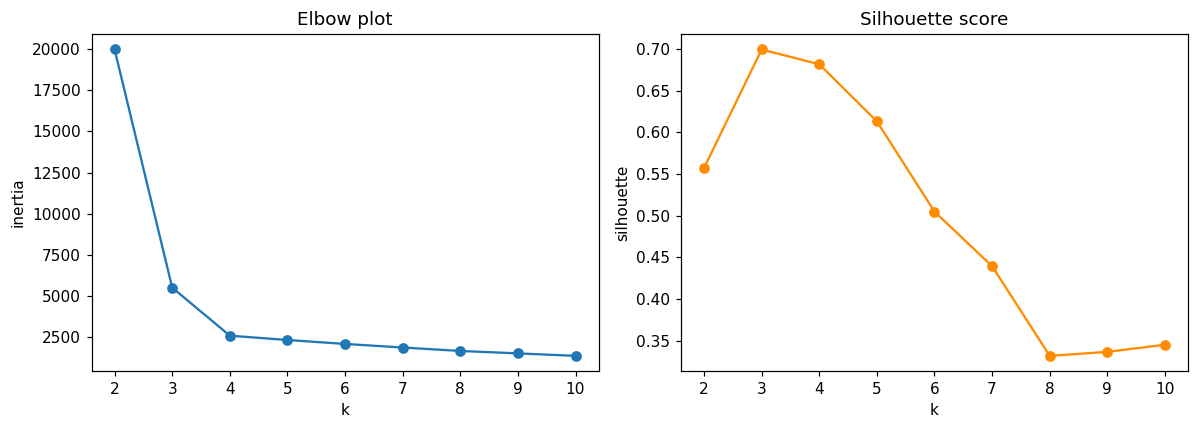

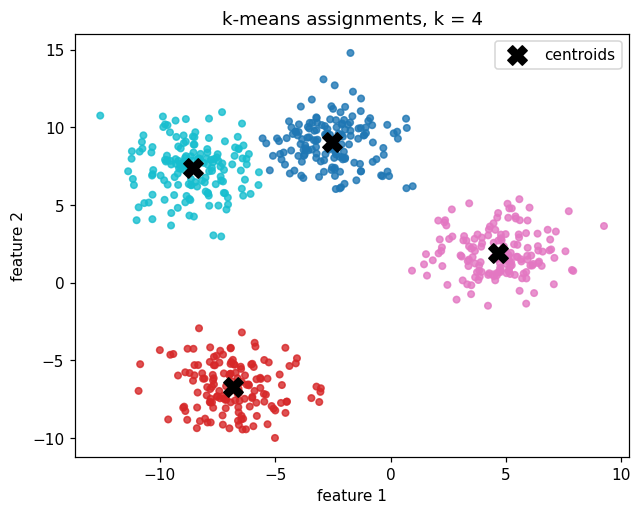

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(ks, inertias, "o-")
axes[0].set_xlabel("k"); axes[0].set_ylabel("inertia"); axes[0].set_title("Elbow plot")
axes[1].plot(ks, sils, "o-", color="darkorange")
axes[1].set_xlabel("k"); axes[1].set_ylabel("silhouette"); axes[1].set_title("Silhouette score")
plt.tight_layout(); plt.show()

k_choice = 4
km_choice = KMeans(n_clusters=k_choice, n_init=10, random_state=42).fit(Xb)
plt.figure(figsize=(6.5, 5))
plt.scatter(Xb[:, 0], Xb[:, 1], c=km_choice.labels_, cmap="tab10", s=18, alpha=0.8)
plt.scatter(km_choice.cluster_centers_[:, 0], km_choice.cluster_centers_[:, 1],
            marker="X", s=160, c="black", label="centroids")
plt.title("k-means assignments, k = %d" % k_choice)
plt.xlabel("feature 1"); plt.ylabel("feature 2"); plt.legend(); plt.show()

**Your answer:**

**Your answer:**

**Your answer:**

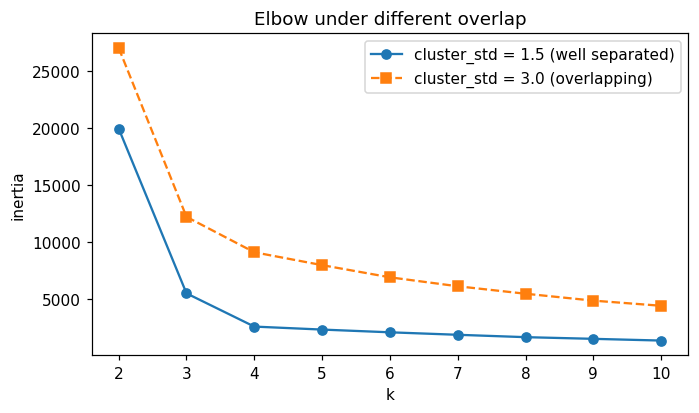

In [4]:
# Counterfactual verification: overlapping blobs
Xb_noisy, yb_noisy = make_blobs(n_samples=600, centers=4, cluster_std=3.0, random_state=42)
inertias_noisy = []
for k in ks:
    km = KMeans(n_clusters=k, n_init=10, random_state=42).fit(Xb_noisy)
    inertias_noisy.append(km.inertia_)

plt.figure(figsize=(7, 3.8))
plt.plot(ks, inertias, "o-", label="cluster_std = 1.5 (well separated)")
plt.plot(ks, inertias_noisy, "s--", label="cluster_std = 3.0 (overlapping)")
plt.xlabel("k"); plt.ylabel("inertia"); plt.title("Elbow under different overlap")
plt.legend(); plt.show()

**Your answer:**

### Task 2: Scaling — When Distances Lie

**Experiment (A).** Generate 4 elongated blobs with features on very different scales: feature 0 varies over hundreds (0..1000), feature 1 over fractions (0..1). Cluster with k-means (k=4) on the raw features and on `StandardScaler`-transformed features. Because the true labels are known, compare both against the ground truth with the adjusted Rand index.

In [5]:
rng = np.random.RandomState(42)
centers = np.array([[200.0, 0.2], [700.0, 0.7], [300.0, 0.8], [800.0, 0.3]])
Xa, ya = [], []
for i, c in enumerate(centers):
    Xa.append(rng.normal(c, [60.0, 0.15], size=(150, 2)))
    ya.append(np.full(150, i))
Xa = np.vstack(Xa); ya = np.concatenate(ya)
print("Feature scales: x in [%.0f, %.0f], y in [%.2f, %.2f]" % (Xa[:, 0].min(), Xa[:, 0].max(), Xa[:, 1].min(), Xa[:, 1].max()))

km_raw = KMeans(n_clusters=4, n_init=10, random_state=42).fit(Xa)
Xa_scaled = StandardScaler().fit_transform(Xa)
km_scaled = KMeans(n_clusters=4, n_init=10, random_state=42).fit(Xa_scaled)

print("ARI vs true blobs | raw features: %.3f | scaled features: %.3f" %
      (adjusted_rand_score(ya, km_raw.labels_), adjusted_rand_score(ya, km_scaled.labels_)))

Feature scales: x in [6, 944], y in [-0.13, 1.19]
ARI vs true blobs | raw features: 0.640 | scaled features: 0.884


**Evidence (C).** Plot the two sets of assignments (raw and scaled) and mark the centroids. The scaled plot should be read in scaled coordinates.

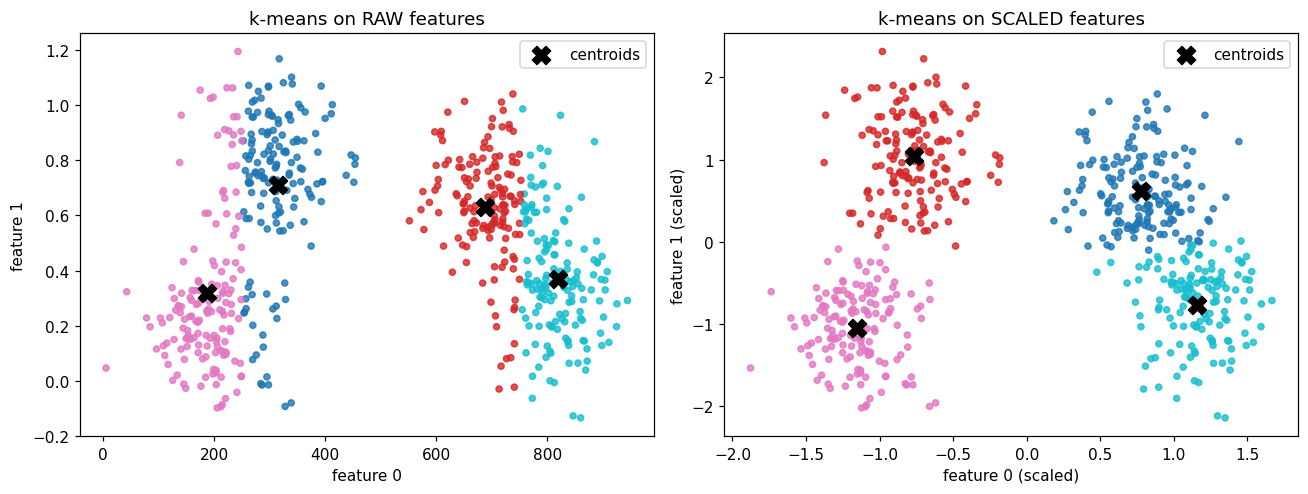

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))
for ax, Xplot, labels, cents, title in [
        (axes[0], Xa, km_raw.labels_, km_raw.cluster_centers_, "k-means on RAW features"),
        (axes[1], Xa_scaled, km_scaled.labels_, km_scaled.cluster_centers_, "k-means on SCALED features")]:
    ax.scatter(Xplot[:, 0], Xplot[:, 1], c=labels, cmap="tab10", s=16, alpha=0.8)
    ax.scatter(cents[:, 0], cents[:, 1], marker="X", s=140, c="black", label="centroids")
    ax.set_title(title); ax.legend()
axes[0].set_xlabel("feature 0"); axes[0].set_ylabel("feature 1")
axes[1].set_xlabel("feature 0 (scaled)"); axes[1].set_ylabel("feature 1 (scaled)")
plt.tight_layout(); plt.show()

**Your answer:**

**Your answer:**

**Your answer:**

In [7]:
# Counterfactual verification: scale only one feature
def scale_col(X, j):
    Xs = X.copy()
    Xs[:, j] = (Xs[:, j] - Xs[:, j].mean()) / Xs[:, j].std()
    return Xs

Xa_xonly = scale_col(Xa, 0)
Xa_yonly = scale_col(Xa, 1)
km_xonly = KMeans(n_clusters=4, n_init=10, random_state=42).fit(Xa_xonly)
km_yonly = KMeans(n_clusters=4, n_init=10, random_state=42).fit(Xa_yonly)
print("ARI | scale x only: %.3f | scale y only: %.3f | scale both: %.3f | scale none: %.3f" %
      (adjusted_rand_score(ya, km_xonly.labels_), adjusted_rand_score(ya, km_yonly.labels_),
       adjusted_rand_score(ya, km_scaled.labels_), adjusted_rand_score(ya, km_raw.labels_)))

ARI | scale x only: 0.892 | scale y only: 0.640 | scale both: 0.884 | scale none: 0.640


**Your answer:**

## Challenge

### Task 3: PCA on Digits — Variance, Scree, and 2-D Structure

**Experiment (A).** Load the digits dataset (1797 handwritten digits, 64 pixels each). Fit PCA without truncating, then examine the explained variance ratio per component and the cumulative share.

In [8]:
digits = load_digits()
Xd, yd = digits.data, digits.target
print("Digits shape:", Xd.shape, "| classes:", np.unique(yd))

pca = PCA().fit(Xd)
evr = pca.explained_variance_ratio_
cum = np.cumsum(evr)
n90 = int(np.argmax(cum >= 0.90)) + 1
n95 = int(np.argmax(cum >= 0.95)) + 1
print("Explained variance: PC1 %.3f, first 2 PCs %.3f, first 10 PCs %.3f" %
      (evr[0], cum[1], cum[9]))
print("Components needed for 90%% variance: %d | for 95%%: %d" % (n90, n95))

Digits shape: (1797, 64) | classes: [0 1 2 3 4 5 6 7 8 9]
Explained variance: PC1 0.149, first 2 PCs 0.285, first 10 PCs 0.738
Components needed for 90% variance: 21 | for 95%: 29


**Evidence (C).** Plot the scree (per-component variance) and the cumulative curve; then project the digits onto the first two principal components and color by the true digit.

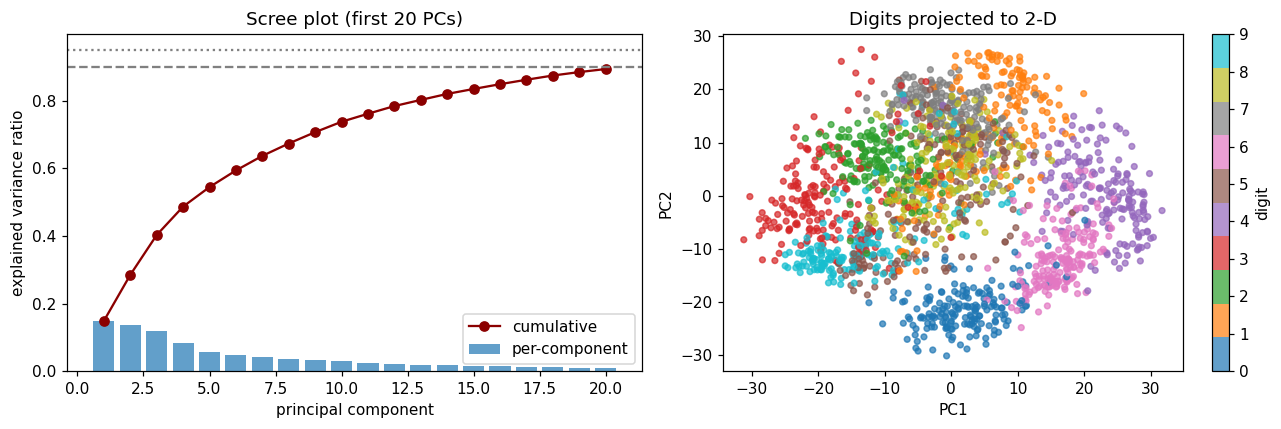

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(np.arange(1, 21), evr[:20], alpha=0.7, label="per-component")
axes[0].plot(np.arange(1, 21), cum[:20], "o-", color="darkred", label="cumulative")
axes[0].axhline(0.90, color="gray", ls="--"); axes[0].axhline(0.95, color="gray", ls=":")
axes[0].set_xlabel("principal component"); axes[0].set_ylabel("explained variance ratio")
axes[0].set_title("Scree plot (first 20 PCs)"); axes[0].legend()

proj2 = PCA(n_components=2, random_state=42).fit_transform(Xd)
sc = axes[1].scatter(proj2[:, 0], proj2[:, 1], c=yd, cmap="tab10", s=14, alpha=0.7)
axes[1].set_xlabel("PC1"); axes[1].set_ylabel("PC2")
axes[1].set_title("Digits projected to 2-D")
plt.colorbar(sc, ax=axes[1], ticks=np.arange(10), label="digit")
plt.tight_layout(); plt.show()

**Your answer:**

**Your answer:**

**Your answer:**

PC1 share | raw pixels: 0.149 | scaled pixels: 0.120


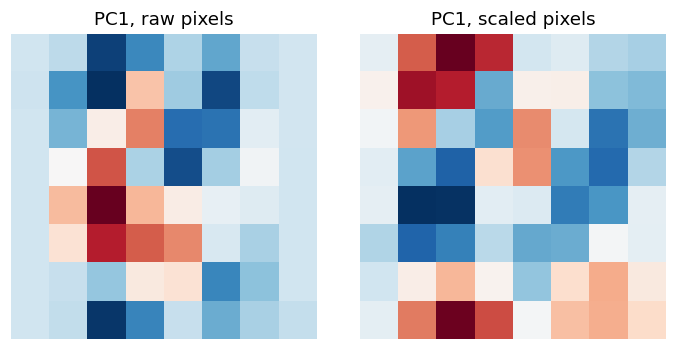

In [10]:
# Counterfactual verification: PCA on scaled pixels
pca_scaled = PCA().fit(StandardScaler().fit_transform(Xd))
evr_s = pca_scaled.explained_variance_ratio_
print("PC1 share | raw pixels: %.3f | scaled pixels: %.3f" % (evr[0], evr_s[0]))

fig, axes = plt.subplots(1, 2, figsize=(6.5, 3.2))
axes[0].imshow(pca.components_[0].reshape(8, 8), cmap="RdBu_r")
axes[0].set_title("PC1, raw pixels")
axes[1].imshow(pca_scaled.components_[0].reshape(8, 8), cmap="RdBu_r")
axes[1].set_title("PC1, scaled pixels")
for ax in axes: ax.axis("off")
plt.tight_layout(); plt.show()

**Your answer:**

### Task 4: PCA + Clustering — and When Distance-Based Clustering Fails

**Experiment (A).** Two experiments:

1. Cluster the digits with k-means (k=10) in the original 64-D pixel space and in a 30-D PCA space; compare both to the true digit labels with ARI. PCA removes noise and speeds up the search.
2. Build a hard case for distance-based clustering: a dense inner core and a thin outer ring (two "natural" clusters that k-means cannot see). Run k-means (k=2) and DBSCAN on it, and compare with ARI.

In [11]:
# (1) k-means on digits: original space vs PCA-30 space
km_orig = KMeans(n_clusters=10, n_init=10, random_state=42).fit(Xd)
pca30 = PCA(n_components=30, random_state=42).fit_transform(Xd)
km_pca = KMeans(n_clusters=10, n_init=10, random_state=42).fit(pca30)
print("Digits k=10, ARI vs true digit | original 64-D: %.3f | PCA-30 space: %.3f" %
      (adjusted_rand_score(yd, km_orig.labels_), adjusted_rand_score(yd, km_pca.labels_)))

Digits k=10, ARI vs true digit | original 64-D: 0.667 | PCA-30 space: 0.668


In [12]:
# (2) concentric rings: k-means cannot see the structure
rng = np.random.RandomState(42)
n_ring = 400
theta = rng.uniform(0, 2 * np.pi, n_ring)
X_ring = np.column_stack([10 * np.cos(theta), 10 * np.sin(theta)]) + rng.normal(0, 0.3, (n_ring, 2))
X_core = rng.normal(0, 1.0, (300, 2))
Xrings = np.vstack([X_ring, X_core])
yrings = np.array([1] * n_ring + [0] * 300)

km_rings = KMeans(n_clusters=2, n_init=10, random_state=42).fit(Xrings)
db_rings = DBSCAN(eps=1.5, min_samples=10).fit(Xrings)
print("Rings: k-means ARI: %.3f | DBSCAN ARI: %.3f" %
      (adjusted_rand_score(yrings, km_rings.labels_), adjusted_rand_score(yrings, db_rings.labels_)))

Rings: k-means ARI: 0.098 | DBSCAN ARI: 1.000


**Evidence (C).** Visualize the ring experiment: ground truth, k-means assignment, DBSCAN assignment.

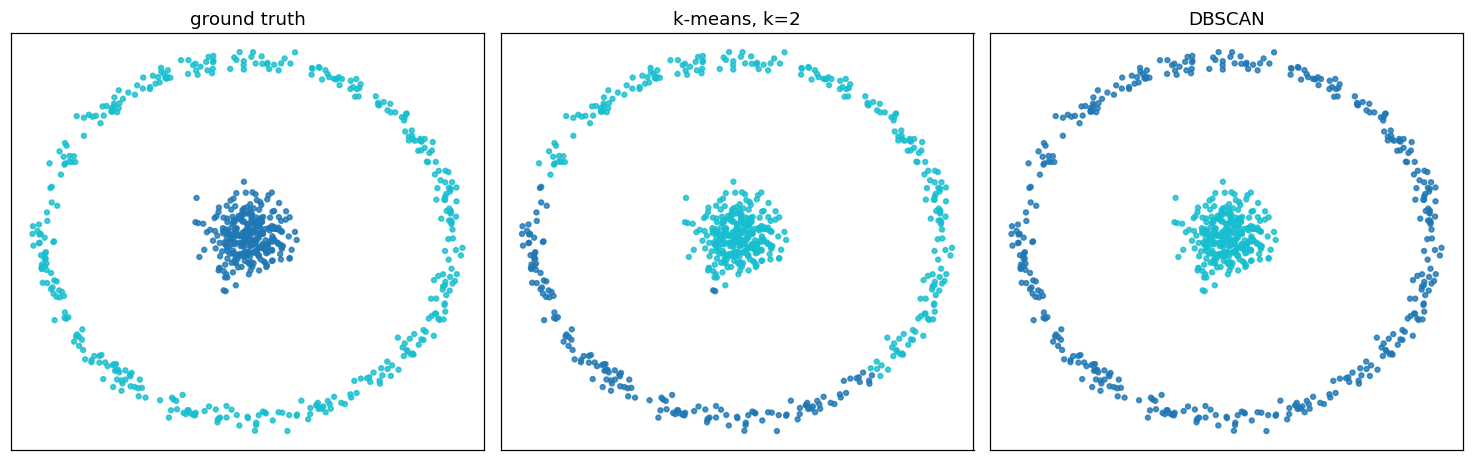

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.3))
datasets = [("ground truth", yrings), ("k-means, k=2", km_rings.labels_), ("DBSCAN", db_rings.labels_)]
for ax, (title, labels) in zip(axes, datasets):
    ax.scatter(Xrings[:, 0], Xrings[:, 1], c=labels, cmap="tab10", s=10, alpha=0.8)
    ax.set_title(title); ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()

**Your answer:**

**Your answer:**

**Your answer:**

---

## Discussion Questions

1. A colleague reports the silhouette score for k=3 as 0.70 and for k=4 as 0.68, and concludes "the data has 3 clusters". The data was actually generated from 4 blobs. What is wrong with treating silhouette as a ground-truth detector?
2. You standardize features before PCA and the first component changes completely. Does that mean PCA is "wrong" on the raw data?
3. When would you prefer DBSCAN over k-means even though k-means is faster and has fewer hyperparameters?

## Takeaways

- Inertia always decreases with k; the elbow and silhouette are *heuristics* — they can disagree with each other and with ground truth. Report the evidence, not just a number.
- k-means optimizes Euclidean distances: features on different scales silently change which features matter. Scale, or do not scale, as a deliberate decision.
- PCA is a tool with two jobs: low-dimensional visualization (2-3 PCs) and noise-reducing compression (e.g., ~90-95% variance). Scaling changes what PCA optimizes.
- Distance-based clustering fails on non-convex shapes (rings, moons); density-based methods like DBSCAN handle them but bring their own hyperparameters.
